# Forecasting Catastrophic Forgetting in CLIP

### A complete machine-learning research project, explained step by step

This notebook contains an entire research study, from raw images through to the final results.
It is written so that a reader with high-school mathematics and a little Python can follow every
step. Each section explains the idea first, then shows the code, then shows what came out.

**The short version of the project.** A large vision model called CLIP already recognises
thousands of everyday objects. If we *specialise* it on a narrow task, such as reading house
numbers or interpreting medical scans, it improves at that task but becomes worse at everything
else. This loss of prior ability is called **catastrophic forgetting**. Our goal is to
**predict how much a model will forget, early in training, before the training run is finished.**

## 0.1 Background: what CLIP is, and what "zero-shot" means

CLIP is a model trained on a very large collection of images paired with their captions. It
learns to place an image and its matching text description close together in a shared
mathematical space.

Because of this, CLIP can classify images **without being trained on that specific task**. To
decide whether a photo shows a cat or a dog, we write two sentences, `"a photo of a cat."` and
`"a photo of a dog."`, convert both the image and the sentences into vectors, and pick the
sentence whose vector is closest to the image vector. Classifying with no task-specific training
is called **zero-shot classification**, and it is the ability we are worried about losing.

## 0.2 Background: fine-tuning and catastrophic forgetting

**Fine-tuning** means continuing to train an already-trained model on a new, narrower dataset.
The model adjusts its internal numbers (its *weights*) to do better on the new task.

The difficulty is that those same weights stored everything the model knew before. Moving them
to fit the new task can overwrite older knowledge. When the loss of prior ability is large, it is
called **catastrophic forgetting**. It matters in practice: an organisation that fine-tunes a
general model for one narrow purpose may not realise how much general capability it destroyed.

## 0.3 The research question

Prior work has shown that you can partly predict forgetting *before* training, using a fixed
score computed on the pretrained model. Our question is different, and is the contribution of
this project:

> **If we watch the model for the first few epochs of fine-tuning, can we forecast how much it
> will have forgotten by the end?**

This is an *early-warning* problem. If it works, a practitioner could stop or adjust a costly
training run early, instead of discovering the damage after paying for the whole thing.

We will compare two sets of inputs:

1. **Static only** - four cheap scores computed before any training begins.
2. **Static plus warm-up** - the same four scores, plus measurements taken during the first few
   epochs of fine-tuning.

If the second set forecasts better, then watching the model learn genuinely adds information.

## 0.4 Roadmap

| Part | Contents |
|---|---|
| 1 | Setup and loading CLIP |
| 2 | The 16 specialised datasets, with images and statistics |
| 3 | Preprocessing: what the model actually receives |
| 4 | Zero-shot classification and the baseline we measure against |
| 5 | Fine-tuning: the training code, plus a small live demonstration |
| 6 | The forgetting curves from the full experiment |
| 7 | The features: static scores and learning-dynamics signals |
| 8 | Framing this as a prediction problem |
| 9 | Five models, compared honestly on unseen datasets |
| 10 | Conclusions and limitations |

## Part 1. Setup

### 1.1 Requirements

This notebook is self-contained. It needs the packages below, and it will download the image
datasets automatically the first time you run it (roughly 6 GB in total, mostly Food101).

A GPU is recommended but not required. Everything except the short live training demonstration in
Part 5 runs comfortably on a CPU, because the expensive experiment was run in advance and its
results are stored in the `outputs/dynamics/` folder next to this notebook.

In [1]:
# Run this cell once if the packages are missing.
# !pip install open_clip_torch torch torchvision medmnist scikit-learn scipy pandas matplotlib

### 1.2 Imports

We import standard scientific-Python libraries and load the pretrained CLIP model.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import warnings

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Running on:", DEVICE)

Running on: cuda


In [3]:
import open_clip

# ViT-B-32 is a medium-sized CLIP. "openai" selects the original pretrained weights.
model, _, preprocess = open_clip.create_model_and_transforms("ViT-B-32", pretrained="openai")
tokenizer = open_clip.get_tokenizer("ViT-B-32")
model = model.to(DEVICE).eval()

n_params = sum(p.numel() for p in model.parameters())
print(f"CLIP loaded. Total parameters: {n_params/1e6:.1f} million")

CLIP loaded. Total parameters: 151.3 million


`preprocess` is the image pipeline that CLIP expects, and `tokenizer` converts sentences into
numbers. We examine both in Part 3 and Part 4.

## Part 2. The datasets

We fine-tune CLIP separately on **16 specialised datasets**. To make the results easier to
interpret, we group them into three families according to how similar they are to ordinary
internet photographs, which is what CLIP was originally trained on.

| Family | Description | Datasets |
|---|---|---|
| natural | ordinary photographs | OxfordPets, Food101, FGVCAircraft, DTD, EuroSAT |
| digits | numbers, symbols and signs | SVHN, MNIST, GTSRB |
| medical | scans and microscopy | 8 MedMNIST datasets |

A reasonable expectation is that datasets which look least like ordinary photographs will cause
the most forgetting. Part 6 tests whether that expectation is correct.

In [4]:
FAMILY = {
    "OxfordPets": "natural", "Food101": "natural", "FGVCAircraft": "natural",
    "DTD": "natural", "EuroSAT": "natural",
    "SVHN": "digits", "MNIST": "digits", "GTSRB": "digits",
    "pathmnist": "medical", "pneumoniamnist": "medical", "bloodmnist": "medical",
    "dermamnist": "medical", "octmnist": "medical", "retinamnist": "medical",
    "breastmnist": "medical", "organcmnist": "medical",
}
FAMILY_COLOR = {"natural": "#2ca02c", "digits": "#d62728", "medical": "#1f77b4"}
DOMAINS = list(FAMILY)
print(f"{len(DOMAINS)} datasets across {len(set(FAMILY.values()))} families")

16 datasets across 3 families


### 2.1 Loading one example image from each dataset

The helper below returns a single raw (unprocessed) image from a dataset, purely so we can look
at it. Reading one image is fast; we never load an entire dataset into memory here.

In [5]:
import torchvision as tv
import medmnist
from medmnist import INFO

ROOT = "data"

def one_raw_image(name):
    """Return a single raw PIL image from the named dataset."""
    if name == "EuroSAT":      return tv.datasets.EuroSAT(ROOT, download=True)[0][0]
    if name == "GTSRB":        return tv.datasets.GTSRB(ROOT, split="train", download=True)[0][0]
    if name == "FGVCAircraft": return tv.datasets.FGVCAircraft(ROOT, split="trainval", download=True)[0][0]
    if name == "SVHN":         return tv.datasets.SVHN(ROOT, split="train", download=True)[0][0]
    if name == "DTD":          return tv.datasets.DTD(ROOT, split="train", download=True)[0][0]
    if name == "MNIST":        return tv.datasets.MNIST(ROOT, train=True, download=True)[0][0].convert("RGB")
    if name == "OxfordPets":   return tv.datasets.OxfordIIITPet(ROOT, split="trainval", download=True)[0][0]
    if name == "Food101":      return tv.datasets.Food101(ROOT, split="train", download=True)[0][0]
    dataset_class = getattr(medmnist, INFO[name]["python_class"])
    return dataset_class(split="train", root=ROOT, download=True)[0][0].convert("RGB")

example = one_raw_image("OxfordPets")
print("Example image type:", type(example).__name__, "| size:", example.size)

Example image type: Image | size: (394, 500)


### 2.2 A gallery of all 16 datasets

The single most useful thing to do with a new dataset is simply to look at it. The border colour
indicates the family.

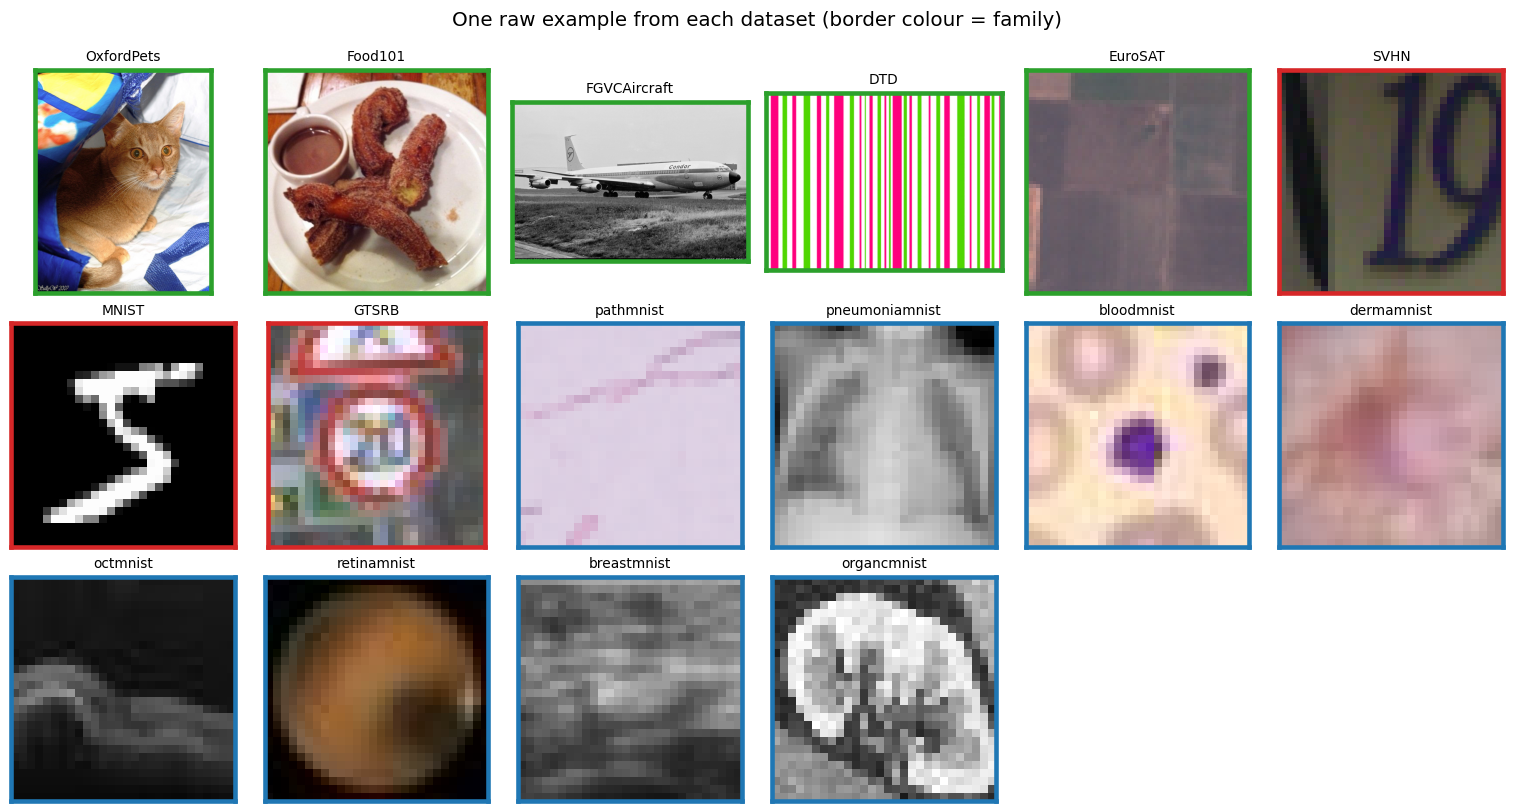

In [6]:
fig, axes = plt.subplots(3, 6, figsize=(14, 7.5))
for ax, name in zip(axes.ravel(), DOMAINS):
    ax.imshow(one_raw_image(name))
    ax.set_title(name, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor(FAMILY_COLOR[FAMILY[name]]); spine.set_linewidth(3)
for ax in axes.ravel()[len(DOMAINS):]:
    ax.axis("off")
fig.suptitle("One raw example from each dataset (border colour = family)", fontsize=13)
plt.tight_layout(); plt.show()

Notice how different the three families look. The medical images are small, low-contrast and
often greyscale. The digit and sign images contain flat colours and sharp symbols. Only the
natural photographs resemble the kind of image CLIP saw during its original training.

### 2.3 Dataset statistics

Beyond appearance, datasets differ in size, number of classes, and image resolution. These
properties affect training, so it is worth tabulating them.

In [7]:
def dataset_stats(name):
    img = one_raw_image(name)
    if name in ("SVHN", "MNIST"):                n_classes = 10
    elif name == "GTSRB":                        n_classes = 43
    elif name in INFO:                           n_classes = len(INFO[name]["label"])
    else:
        loaders = {"EuroSAT": lambda: tv.datasets.EuroSAT(ROOT, download=True).classes,
                   "FGVCAircraft": lambda: tv.datasets.FGVCAircraft(ROOT, split="trainval", download=True).classes,
                   "DTD": lambda: tv.datasets.DTD(ROOT, split="train", download=True).classes,
                   "OxfordPets": lambda: tv.datasets.OxfordIIITPet(ROOT, split="trainval", download=True).classes,
                   "Food101": lambda: tv.datasets.Food101(ROOT, split="train", download=True).classes}
        n_classes = len(loaders[name]())
    return dict(dataset=name, family=FAMILY[name], classes=n_classes,
                width=img.size[0], height=img.size[1])

stats = pd.DataFrame([dataset_stats(n) for n in DOMAINS]).set_index("dataset")
display(stats)

,family,classes,width,height
dataset,,,,
OxfordPets,natural,37,394,500
Food101,natural,101,512,512
FGVCAircraft,natural,100,1024,695
DTD,natural,47,640,480
EuroSAT,natural,10,64,64
SVHN,digits,10,32,32
MNIST,digits,10,28,28
GTSRB,digits,43,29,30
pathmnist,medical,9,28,28


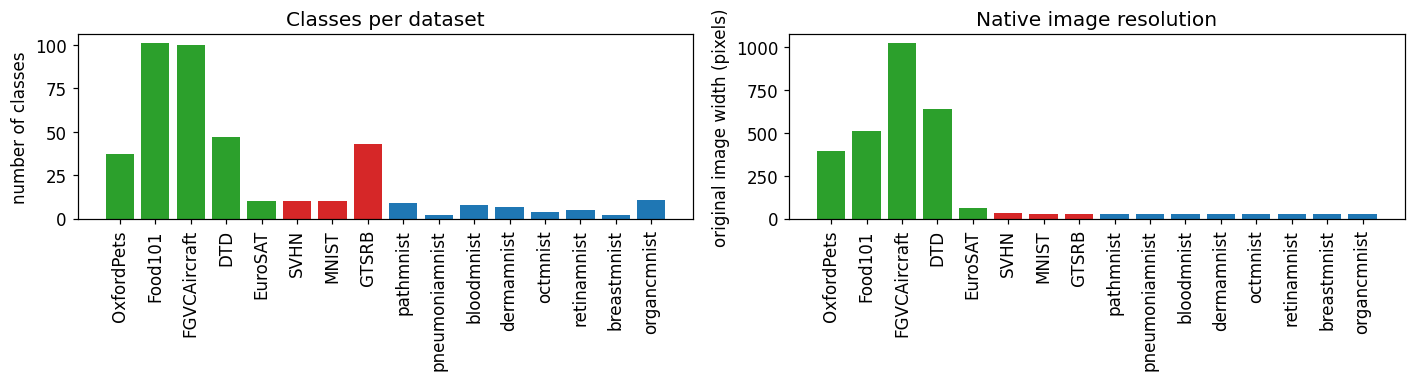

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
colors = [FAMILY_COLOR[FAMILY[d]] for d in stats.index]
ax[0].bar(stats.index, stats.classes, color=colors)
ax[0].set_ylabel("number of classes"); ax[0].set_title("Classes per dataset")
ax[0].tick_params(axis="x", rotation=90)
ax[1].bar(stats.index, stats.width, color=colors)
ax[1].set_ylabel("original image width (pixels)"); ax[1].set_title("Native image resolution")
ax[1].tick_params(axis="x", rotation=90)
plt.tight_layout(); plt.show()

The resolution chart explains a practical problem. Several medical datasets are only 28 by 28
pixels, while CLIP expects 224 by 224. Those images must be enlarged roughly eightfold, which
makes them blurry. This is one reason the medical family behaves differently later on.

## Part 3. Preprocessing: what the model actually receives

A neural network cannot read a picture file. Every image passes through a fixed pipeline that
produces a grid of numbers of exactly the right shape:

1. **Resize** so the shorter side is 224 pixels.
2. **Centre-crop** to exactly 224 by 224.
3. **Convert to a tensor**, so pixels become numbers between 0 and 1.
4. **Normalise**, subtracting a mean and dividing by a standard deviation for each colour channel.

Step 4 deserves a comment. Normalisation re-centres the pixel values so they sit roughly between
-2 and +2 instead of 0 and 1. Models train more reliably when their inputs are centred near zero
and have a similar scale.

In [9]:
# The exact constants CLIP uses to normalise images.
CLIP_MEAN = torch.tensor([0.48145466, 0.4578275, 0.40821073]).view(3, 1, 1)
CLIP_STD  = torch.tensor([0.26862954, 0.26130258, 0.27577711]).view(3, 1, 1)

def undo_normalisation(tensor):
    """Convert a preprocessed tensor back to a viewable image, for display only."""
    return (tensor * CLIP_STD + CLIP_MEAN).clamp(0, 1).permute(1, 2, 0).numpy()

print("preprocess pipeline:"); print(preprocess)

preprocess pipeline:
Compose(
    Resize(size=224, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    <function _convert_to_rgb at 0x7f3cd5e5f400>
    ToTensor()
    Normalize(mean=(0.48145466, 0.4578275, 0.40821073), std=(0.26862954, 0.26130258, 0.27577711))
)


### 3.1 The pipeline, one step at a time

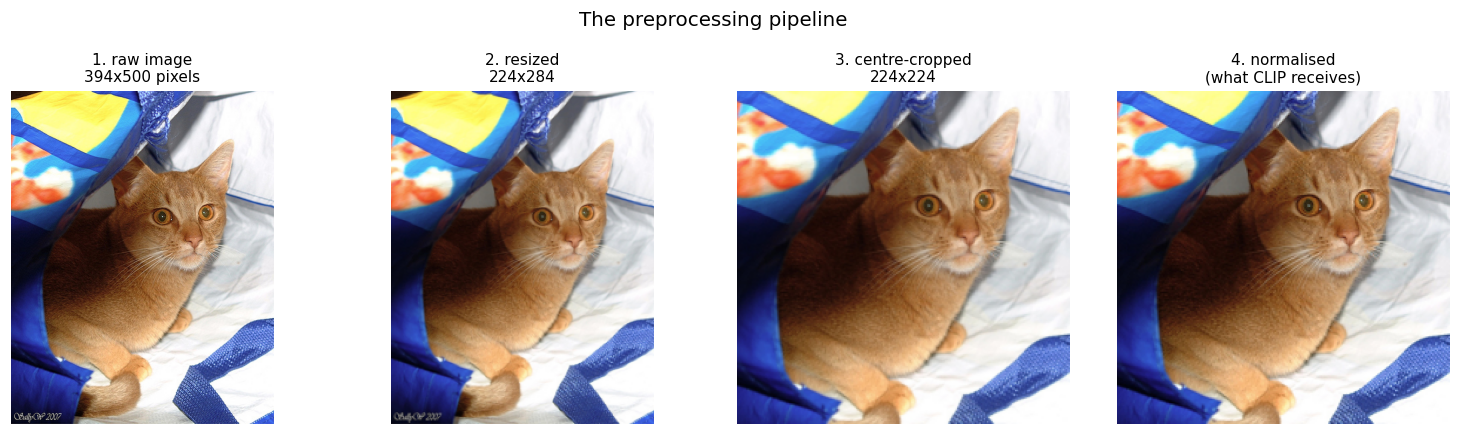

Final tensor shape: (3, 224, 224) (3 colour channels, 224 rows, 224 columns)


In [10]:
raw     = one_raw_image("OxfordPets")
resized = tv.transforms.Resize(224)(raw)
cropped = tv.transforms.CenterCrop(224)(resized)
tensor  = preprocess(raw)          # the real pipeline: resize, crop, to-tensor, normalise

steps = [(raw, f"1. raw image\n{raw.size[0]}x{raw.size[1]} pixels"),
         (resized, f"2. resized\n{resized.size[0]}x{resized.size[1]}"),
         (cropped, "3. centre-cropped\n224x224"),
         (undo_normalisation(tensor), "4. normalised\n(what CLIP receives)")]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, (img, title) in zip(axes, steps):
    ax.imshow(img); ax.set_title(title, fontsize=10); ax.axis("off")
fig.suptitle("The preprocessing pipeline", fontsize=13)
plt.tight_layout(); plt.show()

print("Final tensor shape:", tuple(tensor.shape), "(3 colour channels, 224 rows, 224 columns)")

The fourth image looks colour-shifted. That is expected: it is the normalised version, shown
by reversing the normalisation only approximately for display. The model never sees "colour" at
all, only the numbers.

### 3.2 The image as numbers

To make the point concrete, here is a small 10 by 10 corner of the red channel after
preprocessing, printed as actual numbers.

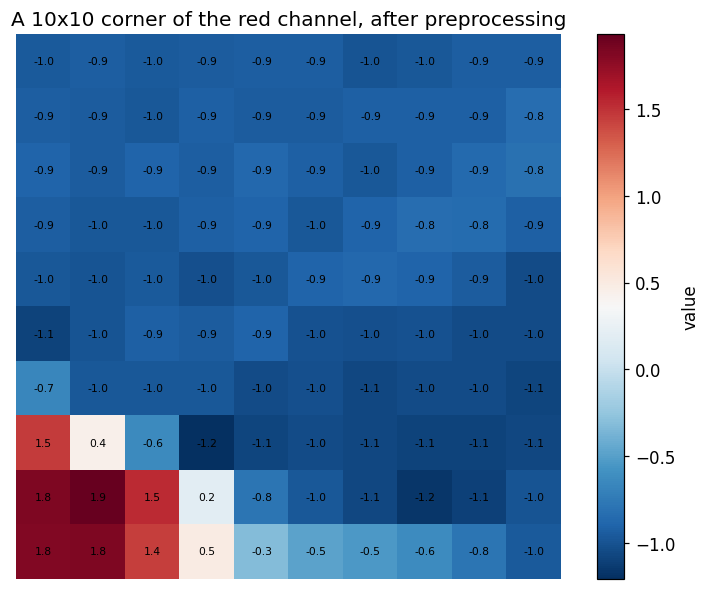

In [11]:
corner = tensor[0, :10, :10].numpy()          # red channel, top-left corner

fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(corner, cmap="RdBu_r")
for (i, j), v in np.ndenumerate(corner):
    ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=7)
ax.set_title("A 10x10 corner of the red channel, after preprocessing")
ax.axis("off"); fig.colorbar(im, label="value")
plt.tight_layout(); plt.show()

### 3.3 What normalisation does to the distribution of pixel values

The histograms below show the same image before and after normalisation. Normalisation does not
change the shape of the distribution; it shifts and rescales it so it is centred near zero.

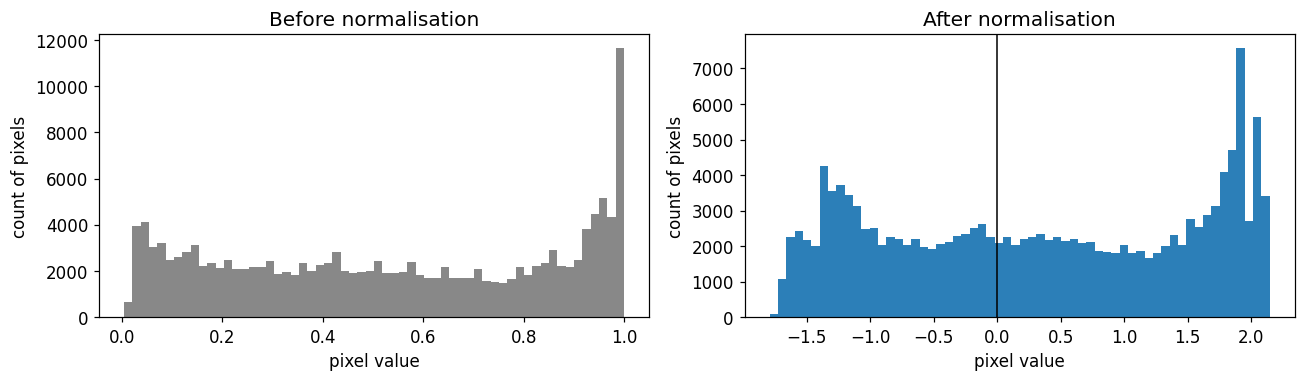

before: mean=+0.537, std=0.324
after : mean=+0.327, std=1.209


In [12]:
before = tv.transforms.ToTensor()(cropped)   # values in [0, 1]
after  = tensor                              # values roughly in [-2, 2]

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].hist(before.flatten().numpy(), bins=60, color="#888")
ax[0].set_title("Before normalisation"); ax[0].set_xlabel("pixel value")
ax[1].hist(after.flatten().numpy(), bins=60, color="#2c7fb8")
ax[1].set_title("After normalisation"); ax[1].set_xlabel("pixel value")
ax[1].axvline(0, color="k", lw=1)
for a in ax: a.set_ylabel("count of pixels")
plt.tight_layout(); plt.show()

print(f"before: mean={before.mean():+.3f}, std={before.std():.3f}")
print(f"after : mean={after.mean():+.3f}, std={after.std():.3f}")

### 3.4 The same preprocessing applied across families

Finally, we apply the full pipeline to one image from each family, to show what the model
receives in each case. The upscaling blur on the medical example is clearly visible.

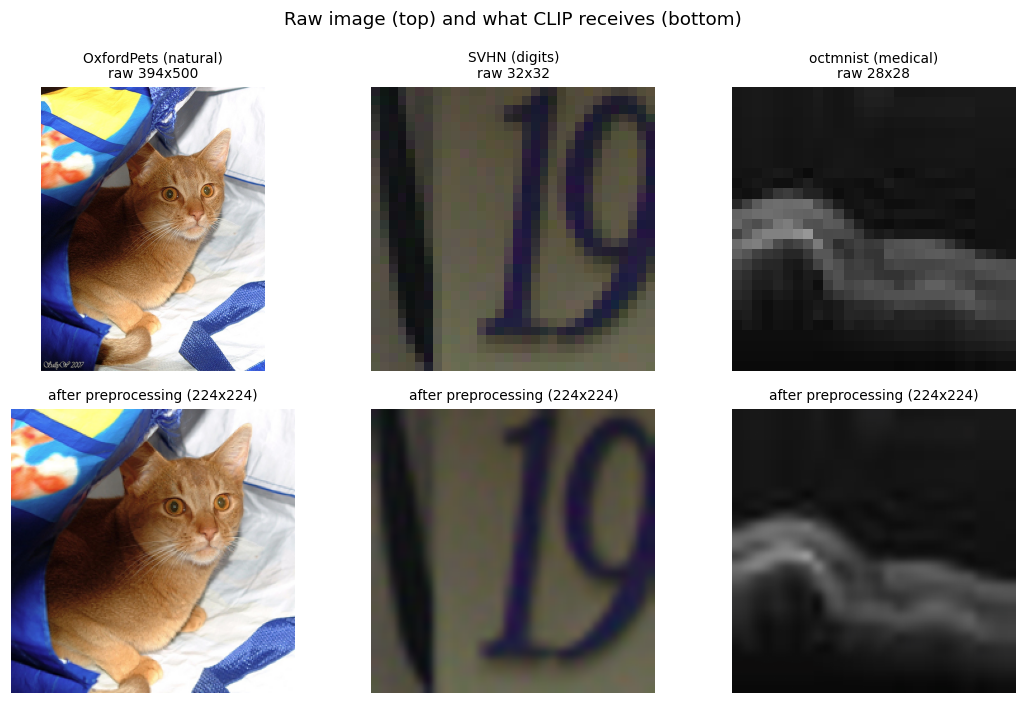

In [13]:
examples = ["OxfordPets", "SVHN", "octmnist"]
fig, axes = plt.subplots(2, 3, figsize=(10, 6.5))
for col, name in enumerate(examples):
    img = one_raw_image(name)
    axes[0, col].imshow(img)
    axes[0, col].set_title(f"{name} ({FAMILY[name]})\nraw {img.size[0]}x{img.size[1]}", fontsize=9)
    axes[1, col].imshow(undo_normalisation(preprocess(img)))
    axes[1, col].set_title("after preprocessing (224x224)", fontsize=9)
for ax in axes.ravel(): ax.axis("off")
fig.suptitle("Raw image (top) and what CLIP receives (bottom)", fontsize=12)
plt.tight_layout(); plt.show()

## Part 4. Zero-shot classification, and the baseline we measure against

Before any fine-tuning, we record how well CLIP performs on three general benchmarks it was
never specifically trained on: **CIFAR-100**, **CIFAR-10** and **STL-10**. These represent the
"general knowledge" we are afraid of losing. Forgetting will be defined as the drop in accuracy
on these three, relative to this baseline.

The classification procedure has three steps:

1. Write one sentence per class, for example `"a photo of a horse."`.
2. Convert each sentence and the image into vectors, and scale each to unit length.
3. Choose the class whose sentence vector has the largest dot product with the image vector.

In [14]:
def make_prompts(class_names):
    """Turn class names into natural sentences, which is what CLIP was trained on."""
    return [f"a photo of a {name.replace('_', ' ')}." for name in class_names]

@torch.no_grad()
def text_classifier(class_names):
    """Encode one sentence per class and normalise -> a matrix of class direction vectors."""
    tokens = tokenizer(make_prompts(class_names)).to(DEVICE)
    return F.normalize(model.encode_text(tokens), dim=-1)

print(make_prompts(["horse", "sports_car"]))

['a photo of a horse.', 'a photo of a sports car.']


### 4.1 A live demonstration of zero-shot classification

We run the pretrained model on a few STL-10 test images and show its top prediction and
confidence. Green indicates a correct prediction, red an incorrect one.

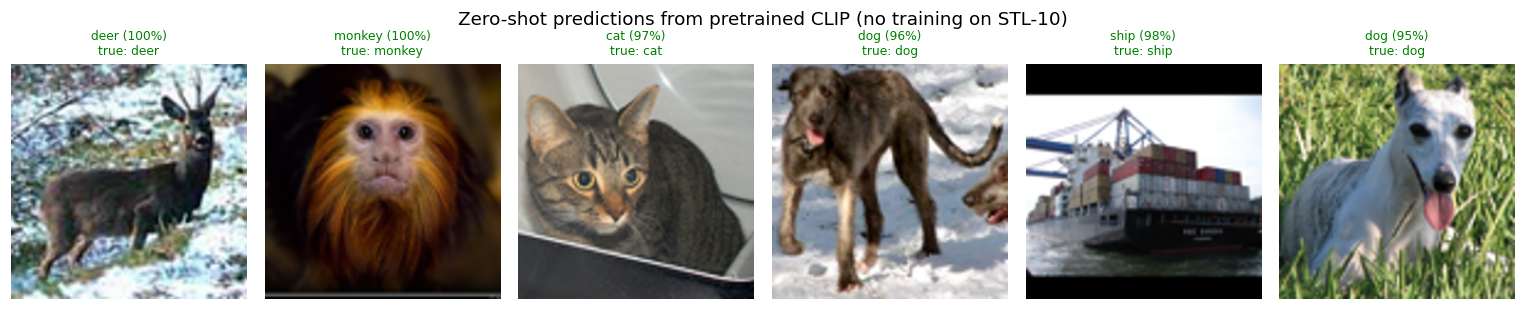

In [15]:
stl = tv.datasets.STL10(ROOT, split="test", transform=preprocess, download=True)
stl_classes = tv.datasets.STL10(ROOT, split="test", download=True).classes
W = text_classifier(stl_classes)

rng = np.random.RandomState(0)
picks = rng.choice(len(stl), 6, replace=False)

fig, axes = plt.subplots(1, 6, figsize=(14, 2.9))
with torch.no_grad():
    for ax, idx in zip(axes, picks):
        image, true_label = stl[idx]
        feats = F.normalize(model.encode_image(image[None].to(DEVICE)), dim=-1)
        probs = (100.0 * feats @ W.T).softmax(dim=-1)[0]
        best = int(probs.argmax())
        ax.imshow(undo_normalisation(image)); ax.axis("off")
        ax.set_title(f"{stl_classes[best]} ({probs[best]:.0%})\ntrue: {stl_classes[true_label]}",
                     fontsize=8, color="green" if best == true_label else "crimson")
fig.suptitle("Zero-shot predictions from pretrained CLIP (no training on STL-10)", fontsize=12)
plt.tight_layout(); plt.show()

### 4.2 The baseline scores

These are the accuracies of the untouched pretrained model. Every forgetting number later in the
notebook is measured as a drop from these values.

,zero-shot accuracy
CIFAR100,0.617
CIFAR10,0.861
STL10,0.956


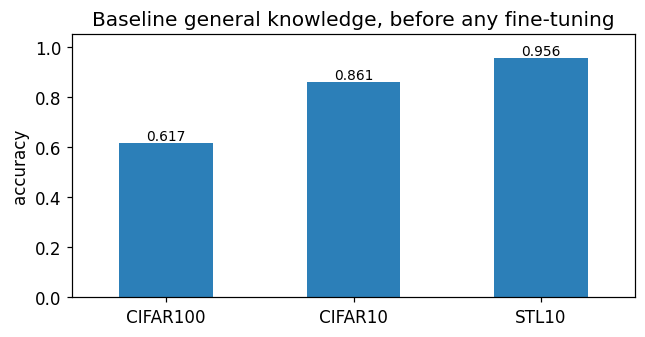

In [16]:
baseline = pd.read_csv("outputs/dynamics/baseline.csv", index_col=0).iloc[:, 0]
display(baseline.rename("zero-shot accuracy").to_frame().round(3))

ax = baseline.plot(kind="bar", figsize=(6, 3.2), color="#2c7fb8", rot=0)
for i, v in enumerate(baseline): ax.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)
ax.set_ylim(0, 1.05); ax.set_ylabel("accuracy")
ax.set_title("Baseline general knowledge, before any fine-tuning")
plt.tight_layout(); plt.show()

## Part 5. Fine-tuning, and how forgetting is measured

### 5.1 The procedure

For each of the 16 datasets we repeat the same experiment:

1. Reset CLIP to its original pretrained weights, so every dataset starts from the same place.
2. Attach a fresh **linear classification head**: a single layer mapping CLIP's image vector to
   the number of classes in the dataset.
3. Train the image encoder and this head on the dataset.
4. After **every epoch**, measure zero-shot accuracy on the three general benchmarks and compute

   `forgetting = baseline accuracy - current accuracy`   (averaged over the three benchmarks)

Two terms worth defining. An **epoch** is one full pass through the training images. The
**learning rate** controls how large a step the model takes at each update; a larger learning
rate changes the weights faster, and as we will see, forgets faster.

We repeat every dataset at **three learning rates** (1e-6, 5e-6, 1e-5), giving 48 training runs
in total. Every dataset is given the same number of training images so that a large dataset does
not appear to cause more forgetting simply because it supplied more training steps.

### 5.2 The training code

This is the actual fine-tuning routine used to produce the results. It is deliberately short.

In [17]:
from torch.utils.data import DataLoader, Subset

def fine_tune_one_epoch(dataset, head, optimizer, batch_size=128):
    """Train the image encoder and the classification head for a single epoch."""
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True,
                        num_workers=4, drop_last=True)
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0
    for images, labels in loader:
        images = images.to(DEVICE)
        labels = torch.as_tensor(labels).long().to(DEVICE)

        logits = head(model.encode_image(images))     # predict the dataset's classes
        loss = F.cross_entropy(logits, labels)        # how wrong the prediction was

        optimizer.zero_grad()
        loss.backward()                               # compute how to change the weights
        optimizer.step()                              # apply the change

        total_loss += loss.item() * len(labels)
        total_correct += (logits.argmax(1) == labels).sum().item()
        total_seen += len(labels)
    model.eval()
    return total_loss / total_seen, total_correct / total_seen

In [18]:
@torch.no_grad()
def zero_shot_accuracy(dataset, class_names, n_images):
    """Standard zero-shot evaluation, used to detect forgetting."""
    idx = np.random.RandomState(42).choice(len(dataset), min(n_images, len(dataset)), replace=False)
    loader = DataLoader(Subset(dataset, idx.tolist()), batch_size=256, num_workers=4)
    W = text_classifier(class_names)
    correct = seen = 0
    model.eval()
    for images, labels in loader:
        feats = F.normalize(model.encode_image(images.to(DEVICE)), dim=-1)
        preds = (100.0 * feats @ W.T).argmax(1).cpu()
        correct += (preds == torch.as_tensor(labels)).sum().item()
        seen += len(labels)
    return correct / seen

### 5.3 A small live demonstration

The full experiment takes several hours, so its results are loaded from file later. To make the
mechanism visible, we run a deliberately small version here: fine-tune on SVHN (house numbers)
for a few epochs at a large learning rate, and watch general knowledge decline in real time.

We use a small image budget so this finishes quickly.

In [19]:
import copy
PRISTINE_WEIGHTS = copy.deepcopy(model.state_dict())   # so we can always restore the original

def reset_model():
    model.load_state_dict(PRISTINE_WEIGHTS)
    model.eval()

# The three general benchmarks used to detect forgetting.
benchmarks = {
    "CIFAR100": (tv.datasets.CIFAR100(ROOT, train=False, transform=preprocess, download=True),
                 tv.datasets.CIFAR100(ROOT, train=False, download=True).classes),
    "CIFAR10":  (tv.datasets.CIFAR10(ROOT, train=False, transform=preprocess, download=True),
                 tv.datasets.CIFAR10(ROOT, train=False, download=True).classes),
    "STL10":    (stl, stl_classes),
}

def measure_general_knowledge(n_images=500):
    return {name: zero_shot_accuracy(ds, cls, n_images) for name, (ds, cls) in benchmarks.items()}

In [20]:
DEMO_EPOCHS = 3
reset_model()
demo_baseline = measure_general_knowledge()
print("Before fine-tuning:", {k: round(v, 3) for k, v in demo_baseline.items()})

svhn = tv.datasets.SVHN(ROOT, split="train", transform=preprocess, download=True)
demo_subset = Subset(svhn, np.random.RandomState(0).choice(len(svhn), 1500, replace=False).tolist())

demo_head = nn.Linear(model.visual.output_dim, 10).to(DEVICE)
demo_opt = torch.optim.AdamW(
    [{"params": model.visual.parameters(), "lr": 1e-5},   # the image encoder
     {"params": demo_head.parameters(),    "lr": 1e-3}],  # the new classification head
    weight_decay=1e-4)

history = []
for epoch in range(1, DEMO_EPOCHS + 1):
    loss, acc = fine_tune_one_epoch(demo_subset, demo_head, demo_opt)
    now = measure_general_knowledge()
    forgetting = float(np.mean([demo_baseline[k] - now[k] for k in demo_baseline]))
    history.append(dict(epoch=epoch, train_loss=loss, train_acc=acc, forgetting=forgetting))
    print(f"epoch {epoch}: SVHN accuracy {acc:.3f} | forgetting so far {forgetting:+.4f}")

demo = pd.DataFrame(history)

Before fine-tuning: {'CIFAR100': 0.598, 'CIFAR10': 0.852, 'STL10': 0.948}


epoch 1: SVHN accuracy 0.262 | forgetting so far +0.1873


epoch 2: SVHN accuracy 0.589 | forgetting so far +0.2580


epoch 3: SVHN accuracy 0.771 | forgetting so far +0.2860


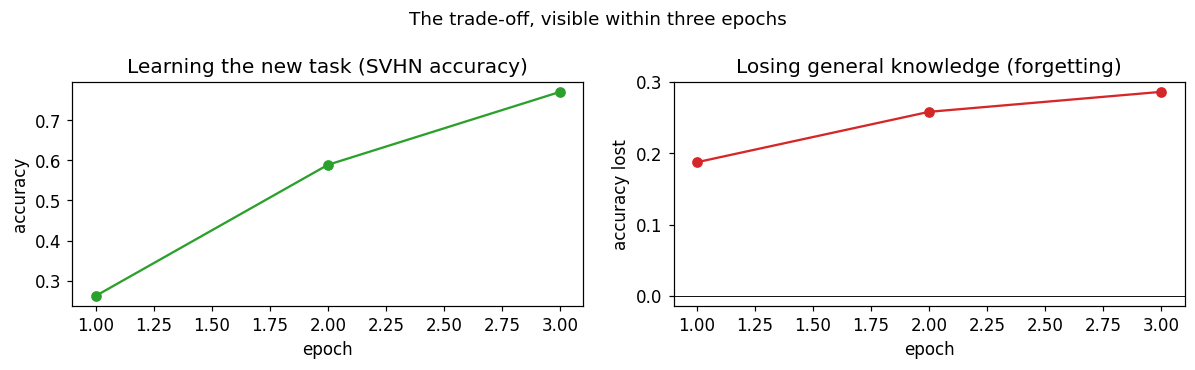

Model restored to its original pretrained weights.


In [21]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(demo.epoch, demo.train_acc, marker="o", color="#2ca02c")
ax[0].set_title("Learning the new task (SVHN accuracy)"); ax[0].set_xlabel("epoch")
ax[0].set_ylabel("accuracy")
ax[1].plot(demo.epoch, demo.forgetting, marker="o", color="#d62728")
ax[1].set_title("Losing general knowledge (forgetting)"); ax[1].set_xlabel("epoch")
ax[1].set_ylabel("accuracy lost"); ax[1].axhline(0, color="k", lw=0.6)
fig.suptitle("The trade-off, visible within three epochs", fontsize=12)
plt.tight_layout(); plt.show()

reset_model()   # restore the pretrained model before continuing
print("Model restored to its original pretrained weights.")

Both effects appear immediately: accuracy on house numbers rises, while general knowledge
falls. The rest of the notebook is about **predicting the right-hand curve in advance**.

### 5.4 The full experiment

The complete study repeats the procedure above for all 16 datasets at 3 learning rates for 20
epochs each, recording five measurements after every epoch. Those results were computed ahead of
time and saved, so the analysis below runs in seconds.

## Part 6. The forgetting curves

We now load the results of the full experiment. Each row is one dataset, at one learning rate,
after one epoch.

In [22]:
curves = pd.read_csv("outputs/dynamics/dynamics_curves.csv")
curves["family"] = curves.domain.map(FAMILY)
print(f"{len(curves)} rows = {curves.domain.nunique()} datasets "
      f"x {curves.lr.nunique()} learning rates x {curves.epoch.max()} epochs")
display(curves.head())

960 rows = 16 datasets x 3 learning rates x 20 epochs


,domain,family,lr,epoch,forgetting,train_loss,train_acc,param_drift,emb_drift
0,EuroSAT,natural,0.000001,1,0.002444,1.563022,0.666583,0.137286,0.379848
1,EuroSAT,natural,0.000001,2,0.017111,0.431410,0.938256,0.218901,0.475877
2,EuroSAT,natural,0.000001,3,0.018889,0.144912,0.968750,0.256591,0.516195
3,EuroSAT,natural,0.000001,4,0.022889,0.079915,0.984879,0.277991,0.516423
4,EuroSAT,natural,0.000001,5,0.024667,0.054647,0.988911,0.293497,0.528714


### 6.1 How forgetting develops during training

Each line is one dataset. The three panels correspond to the three learning rates.

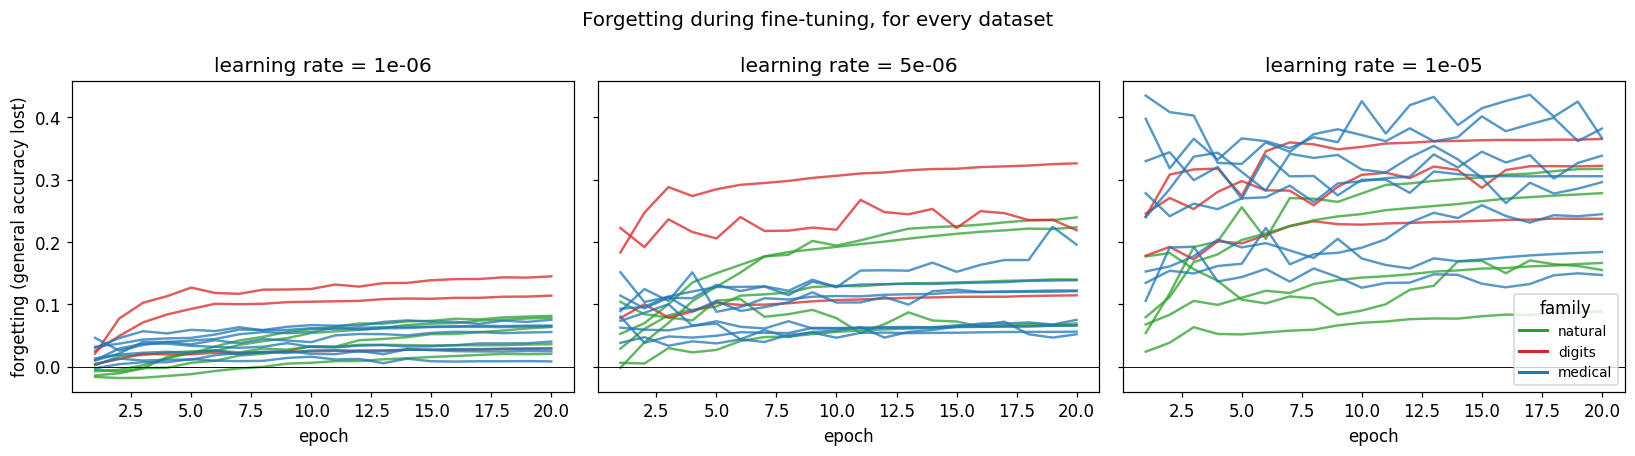

In [23]:
learning_rates = sorted(curves.lr.unique())
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, lr in zip(axes, learning_rates):
    for _, run in curves[curves.lr == lr].groupby("domain"):
        run = run.sort_values("epoch")
        ax.plot(run.epoch, run.forgetting,
                color=FAMILY_COLOR[run.family.iloc[0]], alpha=0.75, lw=1.6)
    ax.set_title(f"learning rate = {lr:g}"); ax.set_xlabel("epoch")
    ax.axhline(0, color="k", lw=0.6)
axes[0].set_ylabel("forgetting (general accuracy lost)")

from matplotlib.lines import Line2D
axes[-1].legend([Line2D([0], [0], color=c, lw=2) for c in FAMILY_COLOR.values()],
                list(FAMILY_COLOR), title="family", fontsize=9)
fig.suptitle("Forgetting during fine-tuning, for every dataset", fontsize=13)
plt.tight_layout(); plt.show()

Two patterns are clear. First, a larger learning rate produces far more forgetting. Second,
the curves separate by family, though not exactly as one might have guessed.

### 6.2 Final forgetting, ranked

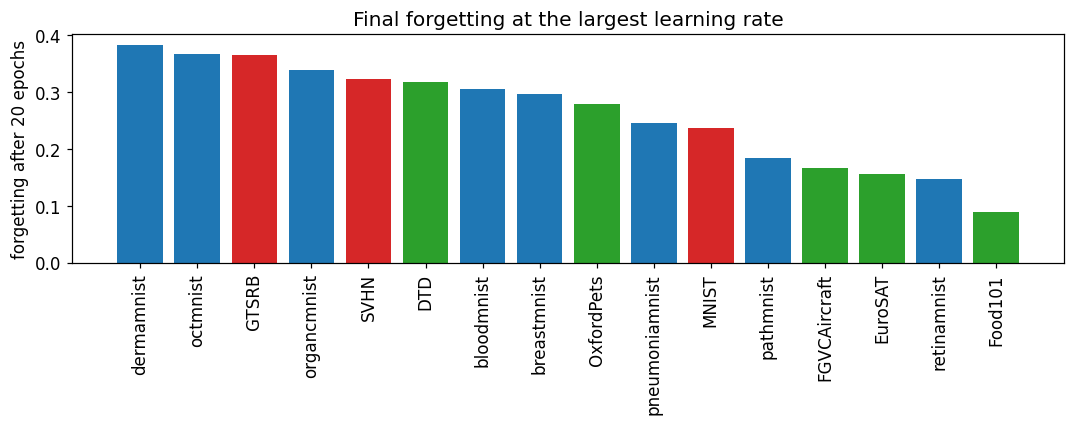

In [24]:
final = curves[curves.epoch == curves.epoch.max()]
ranked = (final[final.lr == final.lr.max()]
          .set_index("domain").forgetting.sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(ranked.index, ranked.values,
       color=[FAMILY_COLOR[FAMILY[d]] for d in ranked.index])
ax.set_ylabel("forgetting after 20 epochs"); ax.tick_params(axis="x", rotation=90)
ax.set_title("Final forgetting at the largest learning rate")
plt.tight_layout(); plt.show()

### 6.3 Forgetting grouped by family

A box plot summarises each family. The box spans the middle half of the values and the line
inside it is the median.

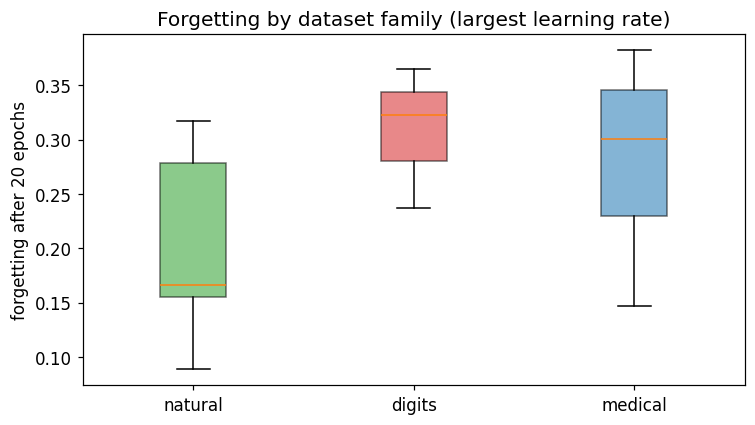

,mean,min,max
family,,,
digits,0.309,0.238,0.366
medical,0.283,0.147,0.382
natural,0.201,0.089,0.318


In [25]:
strongest = final[final.lr == final.lr.max()]
groups = [strongest[strongest.family == f].forgetting.values for f in FAMILY_COLOR]

fig, ax = plt.subplots(figsize=(7, 4))
bp = ax.boxplot(groups, labels=list(FAMILY_COLOR), patch_artist=True)
for patch, colour in zip(bp["boxes"], FAMILY_COLOR.values()):
    patch.set_facecolor(colour); patch.set_alpha(0.55)
ax.set_ylabel("forgetting after 20 epochs")
ax.set_title("Forgetting by dataset family (largest learning rate)")
plt.tight_layout(); plt.show()

display(strongest.groupby("family").forgetting.agg(["mean", "min", "max"]).round(3))

### 6.4 The effect of the learning rate

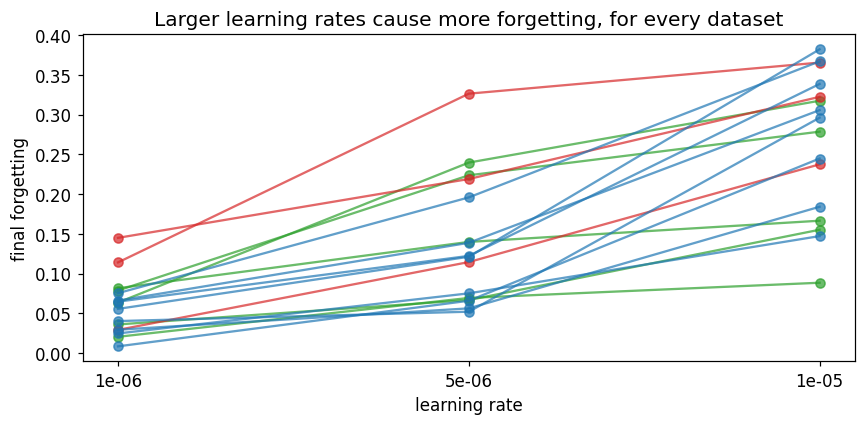

In [26]:
pivot = final.pivot_table(index="domain", columns="lr", values="forgetting")
fig, ax = plt.subplots(figsize=(8, 4))
for domain in pivot.index:
    ax.plot(range(len(learning_rates)), pivot.loc[domain],
            marker="o", color=FAMILY_COLOR[FAMILY[domain]], alpha=0.7)
ax.set_xticks(range(len(learning_rates)))
ax.set_xticklabels([f"{lr:g}" for lr in learning_rates])
ax.set_xlabel("learning rate"); ax.set_ylabel("final forgetting")
ax.set_title("Larger learning rates cause more forgetting, for every dataset")
plt.tight_layout(); plt.show()

## Part 7. The features used for prediction

To predict forgetting we need **features**: measurable quantities we hope are informative. We use
two groups.

### 7.1 Static features, computed before training begins

| Feature | Meaning |
|---|---|
| `semantic_dist` | how poorly pretrained CLIP already classifies the dataset (1 - zero-shot accuracy) |
| `clip_embed_dist` | distance between the dataset's average image vector and that of ordinary photographs |
| `spectral_dist` | difference in texture and sharpness, measured with a Fourier transform and no model at all |
| `frechet_dist` | a distribution-level distance between the dataset and ordinary photographs |

All four are cheap: none of them requires any fine-tuning.

In [27]:
features = pd.read_csv("outputs/dynamics/features.csv")
display(features.set_index("domain").round(3))

,family,semantic_dist,clip_embed_dist,spectral_dist,frechet_dist
domain,,,,,
EuroSAT,natural,0.776,0.326,0.149,0.253
GTSRB,digits,0.717,0.409,0.118,0.326
FGVCAircraft,natural,0.845,0.721,0.029,0.760
SVHN,digits,0.877,0.361,0.123,0.293
DTD,natural,0.598,0.403,0.126,0.315
MNIST,digits,0.645,0.398,0.108,0.342
OxfordPets,natural,0.229,0.587,0.137,0.530
Food101,natural,0.247,0.599,0.134,0.576
pathmnist,medical,0.891,0.367,0.165,0.294


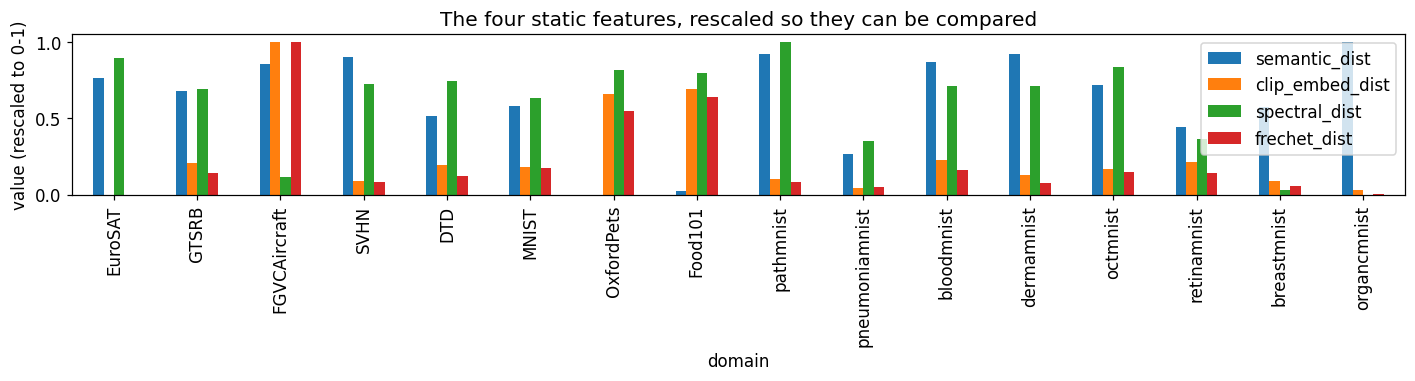

In [28]:
static_cols = ["semantic_dist", "clip_embed_dist", "spectral_dist", "frechet_dist"]
normalised = ((features.set_index("domain")[static_cols] - features[static_cols].min())
              / (features[static_cols].max() - features[static_cols].min()))
normalised.plot(kind="bar", figsize=(13, 3.6))
plt.ylabel("value (rescaled to 0-1)")
plt.title("The four static features, rescaled so they can be compared")
plt.tight_layout(); plt.show()

### 7.2 Dynamic features, measured while the model trains

These are the measurements that make this project different from earlier work. After every epoch
we record five numbers:

| Signal | Meaning |
|---|---|
| `forgetting` | how much general accuracy has been lost so far |
| `train_loss` | how badly the model is doing on the new task |
| `train_acc` | how well the model is doing on the new task |
| `param_drift` | how far the weights have moved from their pretrained values |
| `emb_drift` | how much the model's internal image representations have shifted |

The last two quantify *how much the model has physically changed*, which is a plausible early
indicator of damage.

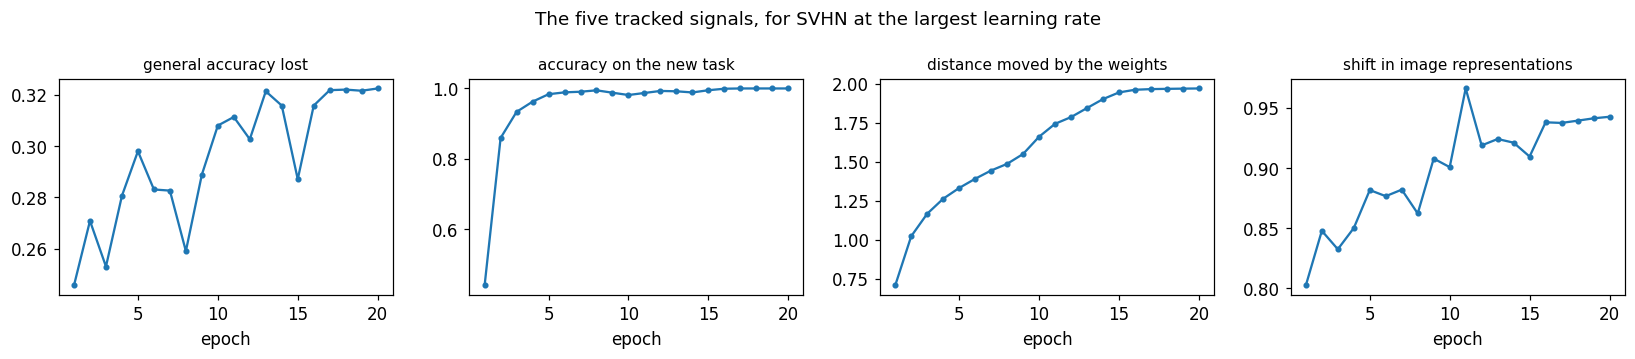

In [29]:
run = curves[(curves.domain == "SVHN") & (curves.lr == curves.lr.max())].sort_values("epoch")

signals = [("forgetting", "general accuracy lost"), ("train_acc", "accuracy on the new task"),
           ("param_drift", "distance moved by the weights"),
           ("emb_drift", "shift in image representations")]
fig, axes = plt.subplots(1, 4, figsize=(15, 3.3))
for ax, (col, title) in zip(axes, signals):
    ax.plot(run.epoch, run[col], marker="o", ms=3)
    ax.set_title(title, fontsize=10); ax.set_xlabel("epoch")
fig.suptitle("The five tracked signals, for SVHN at the largest learning rate", fontsize=12)
plt.tight_layout(); plt.show()

All four signals rise together. That is precisely the pattern we hope to exploit: the early
part of these curves may reveal where the forgetting curve ends up.

### 7.3 Which features relate to final forgetting?

A correlation measures whether two quantities move together. A value near +1 means they rise
together, near -1 means one rises as the other falls, and near 0 means little linear relationship.

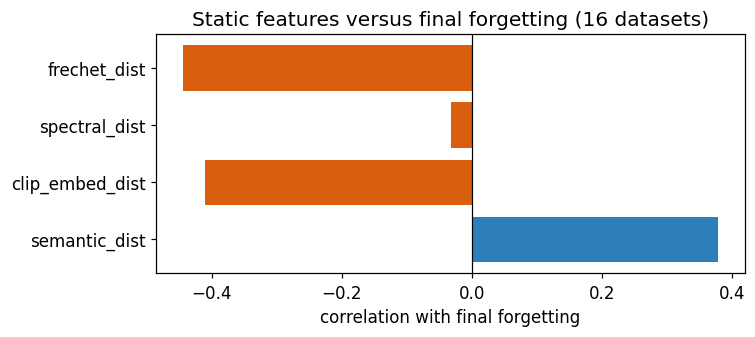

,correlation
semantic_dist,0.379
clip_embed_dist,-0.411
spectral_dist,-0.032
frechet_dist,-0.444


In [30]:
merged = final[final.lr == final.lr.max()].merge(features, on="domain")
corr = merged[static_cols + ["forgetting"]].corr()["forgetting"].drop("forgetting")

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.barh(corr.index, corr.values, color=["#2c7fb8" if v > 0 else "#d95f0e" for v in corr.values])
ax.axvline(0, color="k", lw=0.8); ax.set_xlabel("correlation with final forgetting")
ax.set_title("Static features versus final forgetting (16 datasets)")
plt.tight_layout(); plt.show()
display(corr.round(3).to_frame("correlation"))

These correlations are modest, and they are computed from only 16 datasets, so they are
noisy. This is exactly why we now turn to models that can combine several features at once, and
to the dynamic signals.

## Part 8. Framing this as a prediction problem

We now convert the experiment into a standard supervised-learning table.

- **One row** = one training run, meaning one dataset at one learning rate. That gives
  16 x 3 = 48 rows.
- **The target** (the value to predict) = forgetting at the final epoch.
- **The inputs** = the four static features, the learning rate, and a summary of the first
  `K` epochs, which we call the **warm-up**.

The warm-up summary contains the value of each tracked signal at epoch `K`, plus the slope of the
forgetting curve over those first `K` epochs. We use `K = 5` to begin with.

In [31]:
import forecasting   # the project's small helper module

table = forecasting.build_table(curves, features, K=5)
print(f"{len(table)} rows, {table.domain.nunique()} datasets")
display(table.head(6).round(3))

48 rows, 16 datasets


,domain,family,lr,log_lr,semantic_dist,clip_embed_dist,spectral_dist,frechet_dist,f_warm,loss_warm,acc_warm,pdrift_warm,edrift_warm,fslope_warm,target
0,DTD,natural,0.0,-6.000,0.598,0.403,0.126,0.315,0.006,1.347,0.799,0.238,0.294,0.003,0.064
1,DTD,natural,0.0,-5.301,0.598,0.403,0.126,0.315,0.128,0.490,0.934,0.830,0.700,0.033,0.240
2,DTD,natural,0.0,-5.000,0.598,0.403,0.126,0.315,0.256,0.261,0.974,1.330,0.938,0.049,0.318
3,EuroSAT,natural,0.0,-6.000,0.776,0.326,0.149,0.253,0.025,0.055,0.989,0.293,0.529,0.005,0.036
4,EuroSAT,natural,0.0,-5.301,0.776,0.326,0.149,0.253,0.106,0.018,0.996,0.786,0.775,-0.001,0.067
5,EuroSAT,natural,0.0,-5.000,0.776,0.326,0.149,0.253,0.108,0.032,0.989,1.226,0.763,-0.018,0.155


In [32]:
print("Static inputs :", forecasting.STATIC)
print("Warm-up inputs:", forecasting.WARMUP)
print("Target        : target  (forgetting at the final epoch)")

Static inputs : ['semantic_dist', 'clip_embed_dist', 'spectral_dist', 'frechet_dist', 'log_lr']
Warm-up inputs: ['f_warm', 'loss_warm', 'acc_warm', 'pdrift_warm', 'edrift_warm', 'fslope_warm']
Target        : target  (forgetting at the final epoch)


### 8.1 How we test honestly: leave-one-dataset-out

If we trained and tested on the same datasets, a model could simply memorise them and appear
excellent while being useless in practice. The question we actually care about is:

> Given a **new** dataset that we have never fine-tuned on, can we forecast its forgetting?

To measure this we use **leave-one-dataset-out cross-validation**. We hold out one dataset
entirely, including all three of its learning rates, train on the remaining 15, and predict the
held-out one. We repeat this 16 times so every dataset takes a turn being unseen.

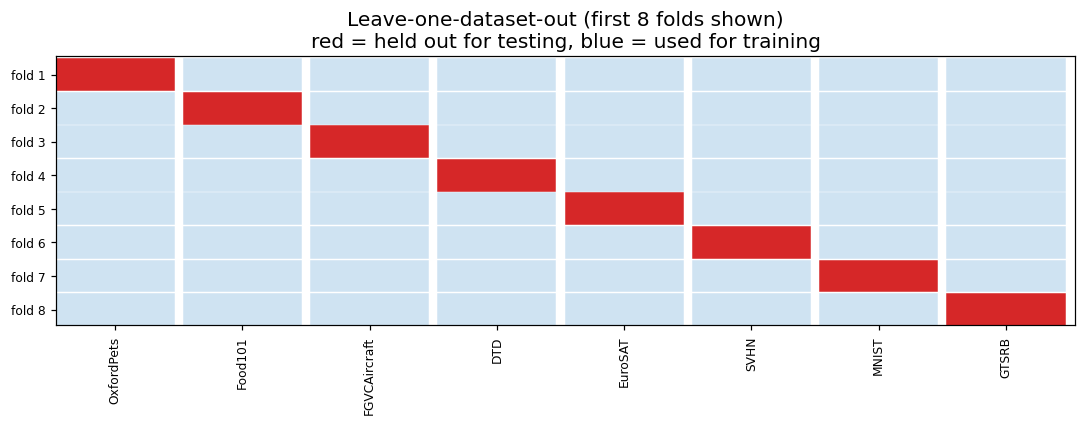

In [33]:
fig, ax = plt.subplots(figsize=(10, 4))
n_show = 8
for fold in range(n_show):
    for j in range(n_show):
        held_out = (j == fold)
        ax.add_patch(plt.Rectangle((j, n_show - fold - 1), 0.92, 0.92,
                                   color="#d62728" if held_out else "#cfe3f2"))
ax.set_xlim(0, n_show); ax.set_ylim(0, n_show)
ax.set_xticks(np.arange(n_show) + 0.46); ax.set_xticklabels(DOMAINS[:n_show], rotation=90, fontsize=8)
ax.set_yticks(np.arange(n_show) + 0.46); ax.set_yticklabels([f"fold {i+1}" for i in range(n_show)][::-1], fontsize=8)
ax.set_title("Leave-one-dataset-out (first 8 folds shown)\nred = held out for testing, blue = used for training")
plt.tight_layout(); plt.show()

### 8.2 How we score a forecast

| Measure | Meaning | Better when |
|---|---|---|
| MAE | mean absolute error, the average size of the mistake | smaller |
| Spearman | agreement in *ranking* which datasets forget most | closer to +1 |
| R-squared | fraction of the variation explained; 0 means no better than always guessing the average, and negative is worse than that | closer to +1 |

## Part 9. Five models, compared

We try five standard models, in increasing order of complexity.

1. **Ridge regression** fits a straight-line combination of the inputs. It is the simplest and
   the easiest to interpret.
2. **Random forest** averages many decision trees, each asking yes/no questions about the inputs.
3. **Gradient boosting** builds trees in sequence, each correcting the previous one's mistakes.
4. **Multi-layer perceptron** is a small neural network that learns its own combination of inputs.
5. **LSTM** is a network designed for sequences. It is the only model that reads the warm-up as an
   ordered time series rather than as a fixed summary.

The central comparison is between using **static features only** and **static features plus the
warm-up**.

In [34]:
results = {}
for label, columns in [("static only", forecasting.STATIC),
                       ("static + warm-up", forecasting.STATIC + forecasting.WARMUP)]:
    results[label] = forecasting.evaluate(table.reset_index(drop=True), columns)

rows = [dict(features=label, model=name, **scores)
        for label, res in results.items() for name, scores in res.items()]
scores_df = pd.DataFrame(rows)
display(scores_df.round(3).set_index(["features", "model"]))

MAE  Spearman     R2
features         model                                   
static only      Ridge (linear)    0.075     0.642  0.397
                 Random Forest     0.070     0.670  0.394
                 Grad Boosting     0.074     0.618  0.306
                 MLP (neural net)  0.122     0.346 -1.133
static + warm-up Ridge (linear)    0.025     0.920  0.911
                 Random Forest     0.025     0.928  0.912
                 Grad Boosting     0.025     0.925  0.917
                 MLP (neural net)  0.113     0.481 -0.660

### 9.1 Adding the LSTM

The LSTM needs the warm-up in its original sequential form, so it is evaluated separately, using
the same leave-one-dataset-out procedure.

In [35]:
lstm_scores, lstm_pred, lstm_true, lstm_domains = forecasting.lstm_lodo(curves, features, K=5, epochs=300)
print("LSTM (static + warm-up sequence):")
for k, v in lstm_scores.items(): print(f"   {k}: {v:.3f}")

LSTM (static + warm-up sequence):
   MAE: 0.038
   Spearman: 0.878
   R2: 0.812


In [36]:
summary = scores_df[scores_df.features == "static + warm-up"][["model", "MAE", "Spearman", "R2"]]
summary = pd.concat([summary, pd.DataFrame([dict(model="LSTM", **lstm_scores)])], ignore_index=True)
display(summary.round(3).set_index("model").sort_values("R2", ascending=False))

,MAE,Spearman,R2
model,,,
Grad Boosting,0.025,0.925,0.917
Random Forest,0.025,0.928,0.912
Ridge (linear),0.025,0.920,0.911
LSTM,0.038,0.878,0.812
MLP (neural net),0.113,0.481,-0.660


### 9.2 Does watching the model learn actually help?

This is the central result of the project.

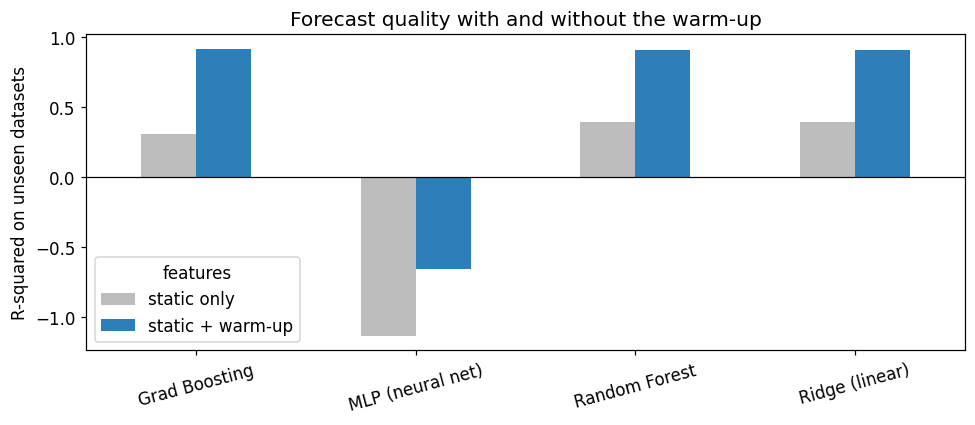

In [37]:
pivot_scores = scores_df.pivot_table(index="model", columns="features", values="R2")
pivot_scores = pivot_scores[["static only", "static + warm-up"]]

ax = pivot_scores.plot(kind="bar", figsize=(9, 4), color=["#bdbdbd", "#2c7fb8"])
ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel("R-squared on unseen datasets"); ax.set_xlabel("")
ax.set_title("Forecast quality with and without the warm-up")
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

For the three well-behaved models, adding the warm-up raises R-squared from roughly 0.3-0.4 to
roughly 0.91, and roughly halves the average error. Watching the first five epochs clearly
carries real information about the final outcome.

The neural network performs poorly in both settings. With only 48 rows there is far too little
data for it to learn anything reliable, and it overfits. This is a genuine and useful lesson:
more complex models are not automatically better, and on small datasets the simpler methods win.

### 9.3 Predicted versus actual

Each point is one held-out training run. Perfect forecasts would lie exactly on the dashed line.

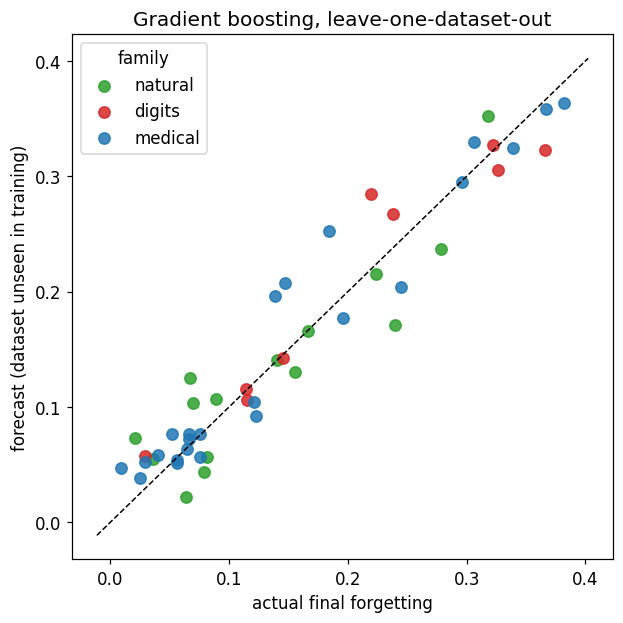

In [38]:
best_columns = forecasting.STATIC + forecasting.WARMUP
predictions = forecasting.lodo(table.reset_index(drop=True), best_columns,
                               forecasting.models()["Grad Boosting"])
actual = table.target.values
fam = table.domain.map(FAMILY).values

fig, ax = plt.subplots(figsize=(5.8, 5.8))
for family, colour in FAMILY_COLOR.items():
    sel = fam == family
    ax.scatter(actual[sel], predictions[sel], color=colour, s=55, alpha=0.85, label=family)
lims = [min(actual.min(), predictions.min()) - 0.02, max(actual.max(), predictions.max()) + 0.02]
ax.plot(lims, lims, "k--", lw=1)
ax.set_xlabel("actual final forgetting"); ax.set_ylabel("forecast (dataset unseen in training)")
ax.legend(title="family"); ax.set_title("Gradient boosting, leave-one-dataset-out")
plt.tight_layout(); plt.show()

### 9.4 Which inputs did the model rely on?

Tree-based models can report how much each input contributed. This tells us *why* the forecast
works.

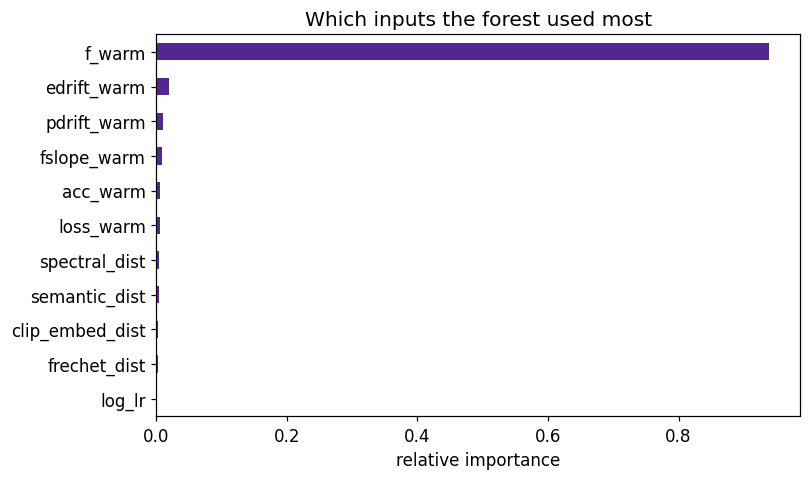

In [39]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(table[best_columns])
forest = RandomForestRegressor(n_estimators=400, random_state=0)
forest.fit(scaler.transform(table[best_columns]), table.target)

importance = pd.Series(forest.feature_importances_, index=best_columns).sort_values()
ax = importance.plot(kind="barh", figsize=(7.5, 4.5), color="#54278f")
ax.set_xlabel("relative importance")
ax.set_title("Which inputs the forest used most")
plt.tight_layout(); plt.show()

### 9.5 How early can the forecast be made?

The warm-up length `K` controls how long we watch before predicting. Shorter is more useful in
practice, because we save more computation. We recompute the whole analysis for each `K`.

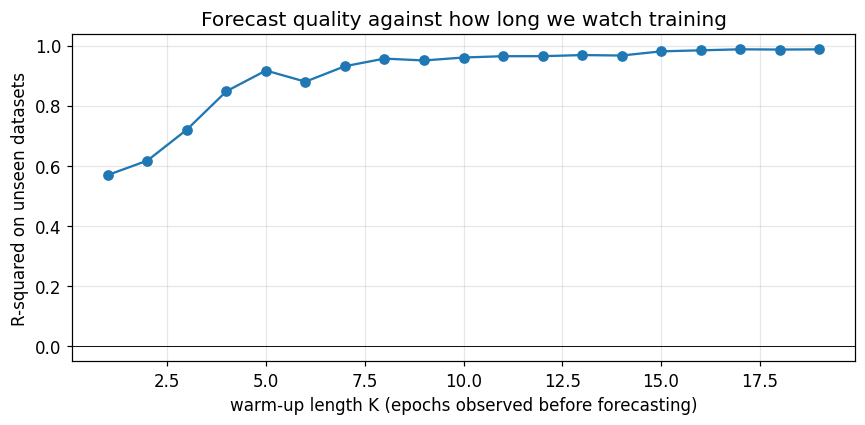

K,1,2,3,4,5,6,7,8,9,10
held_out_R2,0.57,0.618,0.721,0.848,0.917,0.88,0.932,0.957,0.951,0.96


In [40]:
early = forecasting.warmup_curve(curves, features)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(early.K, early.held_out_R2, marker="o")
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("warm-up length K (epochs observed before forecasting)")
ax.set_ylabel("R-squared on unseen datasets")
ax.set_title("Forecast quality against how long we watch training")
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

display(early[early.K <= 10].round(3).set_index("K").T)

Forecast quality climbs steeply over the first few epochs and then flattens. In other words,
most of the useful information arrives early: watching roughly five of twenty epochs, that is a
quarter of the training run, already gives most of the achievable accuracy.

## Part 9.6 Reproducing the full experiment from scratch

Every result above is loaded from `outputs/dynamics/`, which was produced by one script,
`trajectory_dynamics.py`, included alongside this notebook. That script performs the complete
48-run fine-tuning campaign and writes the three files this notebook reads:

- `outputs/dynamics/features.csv` - the four static features per dataset
- `outputs/dynamics/dynamics_curves.csv` - the five signals, per dataset, learning rate and epoch
- `outputs/dynamics/baseline.csv` - the pretrained zero-shot accuracies

To regenerate them from nothing (this takes a few hours on a single GPU), run the script from a
terminal in this folder:

```
python trajectory_dynamics.py --epochs 20 --train-n 4000 --eval-n 1500 --lrs 1e-6 5e-6 1e-5
```

The modelling helper `forecasting.py`, also included, contains the table construction, the five
models, and the leave-one-dataset-out evaluation used in Part 9. Because both scripts and the
cached results are shipped together, this study can be either re-analysed in seconds (this
notebook) or rebuilt end to end (the script).

## Part 10. Conclusions

**What the experiment shows**

1. Forgetting is real and highly uneven. At the largest learning rate, fine-tuning on some
   datasets costs over 30 percent of general accuracy, while others cost almost nothing.
2. The learning rate is the strongest single control on forgetting. The same dataset can be
   nearly harmless or very damaging depending on it.
3. Static, pre-training features alone give only a moderate forecast, with R-squared near 0.4.
4. **Adding a short warm-up of training measurements raises the forecast to roughly 0.91
   R-squared on datasets the model has never seen.** This is the main result: observing the
   first few epochs substantially improves prediction of the final outcome.
5. Simple models beat complicated ones here. Ridge regression, random forests and gradient
   boosting perform almost identically and well; the neural network and the LSTM perform worse,
   because 48 rows is far too little data for them.

**Limitations, stated honestly**

- The study uses **16 datasets**. For judging generalisation to a new dataset, that is a small
  sample, so the numbers carry real uncertainty. Treat the direction of the results as the
  finding, not the third decimal place.
- Part of the task is intrinsically easy: a curve that has begun rising tends to keep rising, so
  some of the warm-up's advantage comes from simple continuation rather than deep insight.
- We used one model architecture, one fine-tuning method, and one optimiser. Whether the same
  relationships hold elsewhere is untested.
- Each configuration was run once. Repeated runs with different random seeds would be needed to
  put error bars on these numbers.

**Reasonable next steps**

- Increase the number of datasets, which is the single change most likely to strengthen the
  conclusions.
- Forecast the entire remaining curve rather than only its final value.
- Investigate *which internal parts* of the model change when forgetting occurs, which would
  turn this predictive result into a mechanistic explanation.